# ML with data obtained by parsing the IUPAC names predicting TDP1 inhibitors 

### Content   <a name="content"></a>

1. [Load and analyse PubChem BioAssay data](#1)
2. [Ensure equal number of both targets](#2)
3. [Balancing](#3)
4. [Machine Learning and cross-validation](#4)
5. [Scrutinize for overfitting](#5)
6. [Hyperparameter tuning with Optuna](#6)
7. [Confidence interval](#7)
8. [Confusion Matrix](#8)
9. [Matthews coefficient](#9)
10. [Classification report](#10)
11. [RFC feature importance](#11)
12. [Chi2 feature importance](#12)
13. [Boruta feature importance](#13)
14. [LIME analyse](#14)

### Load data <a name="1"></a>

In [1]:
import pandas as pd 

# loading the dataset for ML
df = pd.read_csv('data_IUPACs_II.csv', index_col=[0])

# Display the data frame
print('Shape of df: ', df.shape)
df.head()

Shape of df:  (101860, 5963)


,target,acenaphthylene,acenaphthyleno,acetaldehyde,acetamide,acetamido,acetamidoacetyl,acetamidoadamantane,acetamidoanilino,acetamidobenzenesulfonate,...,ynylquinolin,ynylspiro,ynylsulfanyl,ynylsulfanylpyridine,ynylsulfanylpyrido,ynylsulfanylpyrimidin,ynylsulfanyltetrazole,ynylthieno,yohimban,zinc
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


[<a href="#content">Back to top</a>]

## Ensure equal number of target 1 and 0 in the testing set <a name="2"></a>

In [2]:
# from 140,213 samples  
df['target'].value_counts()

target
1    61456
0    40404
Name: count, dtype: int64

In [3]:
# Handle the part of target 0 in the test set 
df_0 = df[df['target']==0]

# Shuffle the resulting data set
df_0 = df_0.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Extract 1650 samples (10% of 16,419 samples) of target 0 for the test set Extract 10% of target 1 for the test set
df_0_test = df_0.iloc[:14100]

# Assign the rest of target 1 for the train set
df_0_train = df_0.iloc[14100:]

In [4]:
# Handle the part of target 1 in the test set 
df_1 = df[df['target']==1]

# Shuffle the resulting data set
df_1 = df_1.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Extract 2800 samples (10% of 28000 samples) of target 1 for the test set
df_1_test = df_1.iloc[:14100]

# Assign the rest of target 1 for the train set
df_1_train = df_1.iloc[14100:]

In [5]:
# Create train and test dataframes for further manipulation 
train = pd.concat([df_0_train, df_1_train])
test = pd.concat([df_0_test, df_1_test])

In [6]:
# Shuffle the resulting data sets
train = train.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

# Shuffle the resulting data set
test = test.sample(
    frac = 1,        # Return entire dataframe
    random_state=1   # Make result reproducible
    ).reset_index(drop=True)

In [7]:
# Create the sets for ML 
X_train = train.drop(columns='target', axis=1)
y_train = train['target']
X_test =  test.drop(columns='target', axis=1)
y_test = test['target']

In [8]:
# Create the sets for Cross-validation
X = pd.concat([X_train, X_test])
y = pd.concat([y_train,y_test])

In [9]:
# Check the number of classes in the y_test set
y_test.value_counts()

target
1    14100
0    14100
Name: count, dtype: int64

In [10]:
# Keeping sets for the cross validation  
X_cv = X_train.reset_index(drop=True)
y_cv = y_train.reset_index(drop=True)

In [11]:
# Print X_cv
X_cv.head()

,acenaphthylene,acenaphthyleno,acetaldehyde,acetamide,acetamido,acetamidoacetyl,acetamidoadamantane,acetamidoanilino,acetamidobenzenesulfonate,acetamidobenzoate,...,ynylquinolin,ynylspiro,ynylsulfanyl,ynylsulfanylpyridine,ynylsulfanylpyrido,ynylsulfanylpyrimidin,ynylsulfanyltetrazole,ynylthieno,yohimban,zinc
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Print y_cv
y_cv.head()

0    0
1    1
2    1
3    1
4    1
Name: target, dtype: int64

[<a href="#content">Back to top</a>]

## Balance data  <a name="3"></a>

[(0, 26304), (1, 47356)]


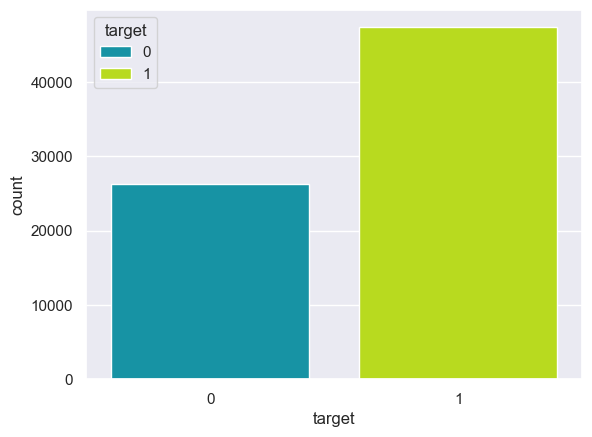

In [13]:
from collections import Counter
from matplotlib import pyplot as plt
import seaborn as sns

# Illustrate the imbalance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train, palette='nipy_spectral')
plt.show()

[(0, 47356), (1, 47356)]


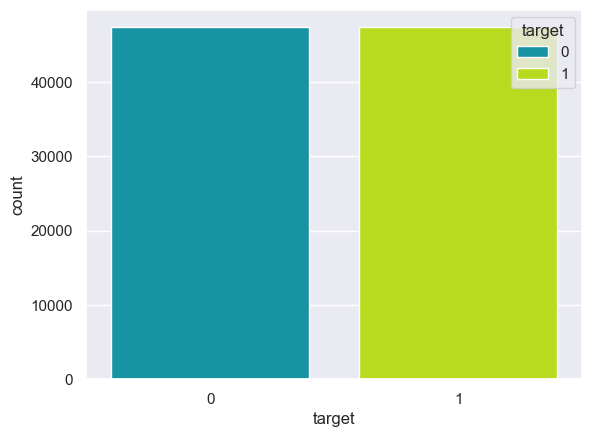

In [14]:
from imblearn.over_sampling import SMOTE

# Balance targets with SMOTE
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

# Illustrate the balance between classification targets 
print(sorted(Counter(y_train).items()))
sns.set_style('white')
sns.set(font_scale=1)
plt.figure()
sns.countplot(x=y_train, hue=y_train,palette='nipy_spectral')
plt.show()

[<a href="#content">Back to top</a>]

## Machine learning and cross validation  <a name="4"></a>

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import matplotlib.pyplot as plt

# Instantiate the estimator 
model = RandomForestClassifier(random_state=42)

# Train  
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.783
Precision:  0.836
Recall:  0.705
F1:  0.765
ROC:  0.783


In [16]:
# Five-fold cross-validation 
import numpy as np 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

# Number of folds
n_splits = 5

# Stratified K-Fold ensures balanced class distribution in each fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics from each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Cross-Validation Loop with Resampling
print(f"Performing {n_splits}-Fold Stratified Cross-Validation with SMOTE...\n")

for fold, (train_index, test_index) in enumerate(skf.split(X_cv, y_cv)):
    print(f"--- Fold {fold + 1}/{n_splits} ---")

    # Split data for the current fold
    X_train_cv, X_test_cv = X_cv.iloc[train_index], X_cv.iloc[test_index]
    y_train_cv, y_test_cv = y_cv.iloc[train_index], y_cv.iloc[test_index]

    # StratifiedKFold ensures similar distribution in train/test
    print(f"  Training set class distribution: {np.bincount(y_train_cv)}")
    print(f"  Test set class distribution: {np.bincount(y_test_cv)}")

    # Define and apply resampling strategy 
    sampler = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_cv, y_train_cv)

    print(f"  Training set (after oversampling) class distribution: {np.bincount(y_train_resampled)}")

    # Train the model on the resampled training data
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the *original, untouched* test data
    y_pred_cv = model.predict(X_test_cv)
    y_prob_cv = model.predict_proba(X_test_cv)[:, 1] # Probability for the positive class (class 1)

    # Evaluate performance for the current fold
    accuracy = accuracy_score(y_test_cv, y_pred_cv)
    precision = precision_score(y_test_cv, y_pred_cv, zero_division=0)
    recall = recall_score(y_test_cv, y_pred_cv, zero_division=0)
    f1 = f1_score(y_test_cv, y_pred_cv, zero_division=0)
    roc_auc = roc_auc_score(y_test_cv, y_prob_cv)

    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Confusion Matrix:\n{confusion_matrix(y_test_cv, y_pred_cv)}\n")
    print("-" * 30)

# Aggregate and Report Final Metrics
print("\n--- Cross-Validation Results Summary ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} +/- {np.std(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f} +/- {np.std(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f} +/- {np.std(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} +/- {np.std(f1_scores):.4f}")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} +/- {np.std(roc_auc_scores):.4f}")

# Convert lists to NumPy arrays for easier manipulation
all_scores = {
    'accuracy': np.array(accuracy_scores),
    'precision': np.array(precision_scores),
    'recall': np.array(recall_scores),
    'f1_score': np.array(f1_scores),
    'roc_auc': np.array(roc_auc_scores)
}

Performing 5-Fold Stratified Cross-Validation with SMOTE...

--- Fold 1/5 ---
  Training set class distribution: [21043 37885]
  Test set class distribution: [5261 9471]
  Training set (after oversampling) class distribution: [37885 37885]
  Accuracy: 0.7528
  Precision: 0.8963
  Recall: 0.6960
  F1-Score: 0.7835
  ROC AUC: 0.8564
  Confusion Matrix:
[[4498  763]
 [2879 6592]]

------------------------------
--- Fold 2/5 ---
  Training set class distribution: [21043 37885]
  Test set class distribution: [5261 9471]
  Training set (after oversampling) class distribution: [37885 37885]
  Accuracy: 0.7488
  Precision: 0.8923
  Recall: 0.6929
  F1-Score: 0.7800
  ROC AUC: 0.8524
  Confusion Matrix:
[[4469  792]
 [2909 6562]]

------------------------------
--- Fold 3/5 ---
  Training set class distribution: [21043 37885]
  Test set class distribution: [5261 9471]
  Training set (after oversampling) class distribution: [37885 37885]
  Accuracy: 0.7624
  Precision: 0.8979
  Recall: 0.7113
  

[<a href="#content">Back to top</a>]

## Scrutinizing for overfitting  <a name="5"></a>

In [17]:
# Evaluate random forest classifier performance on train and test sets with different tree depths
train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 31)]
# evaluate a decision tree for each depth
for i in values:
 # configure the model
 model_ = RandomForestClassifier(max_depth=i)
 # fit model_ on the training dataset
 model_.fit(X_train, y_train)
 # evaluate on the train dataset
 train_yhat = model_.predict(X_train)
 train_acc = accuracy_score(y_train, train_yhat)
 train_scores.append(train_acc)
 # evaluate on the test dataset
 test_yhat = model_.predict(X_test)
 test_acc = accuracy_score(y_test, test_yhat)
 test_scores.append(test_acc)
 # summarize progress
 print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.658, test: 0.627
>2, train: 0.680, test: 0.651
>3, train: 0.697, test: 0.661
>4, train: 0.696, test: 0.664
>5, train: 0.707, test: 0.671
>6, train: 0.711, test: 0.668
>7, train: 0.706, test: 0.669
>8, train: 0.716, test: 0.673
>9, train: 0.715, test: 0.675
>10, train: 0.725, test: 0.682
>11, train: 0.730, test: 0.685
>12, train: 0.726, test: 0.679
>13, train: 0.734, test: 0.687
>14, train: 0.739, test: 0.692
>15, train: 0.739, test: 0.690
>16, train: 0.744, test: 0.694
>17, train: 0.743, test: 0.692
>18, train: 0.747, test: 0.694
>19, train: 0.751, test: 0.699
>20, train: 0.760, test: 0.707
>21, train: 0.761, test: 0.702
>22, train: 0.764, test: 0.705
>23, train: 0.774, test: 0.711
>24, train: 0.777, test: 0.715
>25, train: 0.776, test: 0.712
>26, train: 0.777, test: 0.712
>27, train: 0.785, test: 0.715
>28, train: 0.787, test: 0.717
>29, train: 0.791, test: 0.719
>30, train: 0.794, test: 0.722


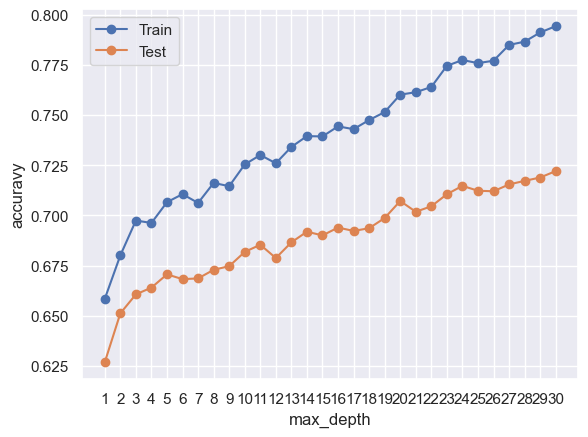

In [18]:
import math
import matplotlib.pyplot as plt

# Set integers for x axis
new_x_ticks = range(math.floor(min(values)), math.ceil(max(values))+1)
plt.xticks(new_x_ticks)
# Plot of train and test scores vs tree depth
plt.plot(values, train_scores, '-o', label='Train')
plt.plot(values, test_scores, '-o', label='Test')
plt.legend()
plt.xlabel("max_depth")
plt.ylabel("accuravy")
plt.show()

In [19]:
# ML model with max_depth=23
# Instantiate the estimator 
model = RandomForestClassifier(max_depth=17, random_state=42)

# Train  
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.697
Precision:  0.715
Recall:  0.657
F1:  0.685
ROC:  0.697


[<a href="#content">Back to top</a>]

 ## Hyperparameter tuning with Optuna <a name="6"></a>

In [20]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

def objective(trial):
    """Objective function for Optuna."""

    # Define hyperparameters to search
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 32),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }

    # Create the Random Forest Classifier
    clf = RandomForestClassifier(random_state=42, **param)

    # Cross-validation using only the training data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

    # Return the mean cross-validation score
    return scores.mean()

# Create an Optuna study
study = optuna.create_study(direction='maximize')

# Optimize the objective function
study.optimize(objective, n_trials=5)

# Get the best hyperparameters
best_params = study.best_params
best_score = study.best_value

print("Best Parameters:", best_params)
print("Best Score (CV on Training Data):", best_score)

# Train the final model with the best parameters on the *entire* training set
final_clf = RandomForestClassifier(random_state=42, **best_params)
final_clf.fit(X_train, y_train)

# Evaluate the final model on the test set
test_score = final_clf.score(X_test, y_test)
print("Test Score (on Test Data):", test_score)

[I 2025-10-27 01:02:25,760] A new study created in memory with name: no-name-25f30b8c-19ae-4cda-b588-861f6187fa2f
[I 2025-10-27 01:03:53,938] Trial 0 finished with value: 0.7083473806935591 and parameters: {'n_estimators': 70, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7083473806935591.
[I 2025-10-27 05:29:46,457] Trial 1 finished with value: 0.6959413559017248 and parameters: {'n_estimators': 243, 'max_depth': 21, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'criterion': 'entropy'}. Best is trial 0 with value: 0.7083473806935591.
[I 2025-10-27 09:54:31,084] Trial 2 finished with value: 0.7104801548224242 and parameters: {'n_estimators': 202, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': None, 'criterion': 'gini'}. Best is trial 2 with value: 0.7104801548224242.
[I 2025-10-27 09:55:29,654] Trial 3 finished with value: 0.7284610495

Best Parameters: {'n_estimators': 81, 'max_depth': 25, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'gini'}
Best Score (CV on Training Data): 0.7284610495875871
Test Score (on Test Data): 0.6956028368794326


In [36]:
''' Optuna:
Best Parameters: {'n_estimators': 404, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}
Best Score (CV on Training Data): 0.7425247495594608
Test Score (on Test Data): 0.7067730496453901'''

" Optuna:\nBest Parameters: {'n_estimators': 404, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}\nBest Score (CV on Training Data): 0.7425247495594608\nTest Score (on Test Data): 0.7067730496453901"

[<a href="#content">Back to top</a>]

In [34]:
# ML model with max_depth=8
# Instantiate the estimator 
model = RandomForestClassifier(n_estimators=404,
                               max_depth=8,
                               min_samples_split=10,
                               min_samples_leaf=6,
                               max_features='log2',
                               criterion='gini',
                               random_state=42)

# Train  
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
acc = round(accuracy_score(y_test, y_pred),3)
print('Accuracy: ', acc)
pre = round(precision_score(y_test, y_pred),3)
print('Precision: ', pre) 
rec = round(recall_score(y_test, y_pred),3)
print('Recall: ',rec) 
f1 = round(f1_score(y_test, y_pred),3)
print('F1: ', f1) 
roc = round(roc_auc_score(y_test, y_pred),3) 
print('ROC: ', roc)

Accuracy:  0.707
Precision:  0.714
Recall:  0.691
F1:  0.702
ROC:  0.707


In [35]:
# Evaluate random forest classifier performance on train and test sets with different tree depths
train_scores, test_scores = list(), list()
# define the tree depths to evaluate
values = [i for i in range(1, 31)]
# evaluate a decision tree for each depth
for i in values:
 # configure the model
 model_ = RandomForestClassifier(max_depth=i,
                                 n_estimators=404,
                                 min_samples_split=10,
                                 min_samples_leaf=6,
                                 max_features='log2',
                                 criterion='gini',
                                 random_state=42)
 # fit model_ on the training dataset
 model_.fit(X_train, y_train)
 # evaluate on the train dataset
 train_yhat = model_.predict(X_train)
 train_acc = accuracy_score(y_train, train_yhat)
 train_scores.append(train_acc)
 # evaluate on the test dataset
 test_yhat = model_.predict(X_test)
 test_acc = accuracy_score(y_test, test_yhat)
 test_scores.append(test_acc)
 # summarize progress
 print('>%d, train: %.3f, test: %.3f' % (i, train_acc, test_acc))

>1, train: 0.685, test: 0.652
>2, train: 0.709, test: 0.669
>3, train: 0.720, test: 0.680
>4, train: 0.734, test: 0.693
>5, train: 0.738, test: 0.699
>6, train: 0.740, test: 0.697
>7, train: 0.745, test: 0.703
>8, train: 0.749, test: 0.707
>9, train: 0.745, test: 0.702
>10, train: 0.751, test: 0.707
>11, train: 0.755, test: 0.708
>12, train: 0.754, test: 0.708
>13, train: 0.755, test: 0.710
>14, train: 0.756, test: 0.712
>15, train: 0.757, test: 0.711
>16, train: 0.761, test: 0.714
>17, train: 0.762, test: 0.715
>18, train: 0.763, test: 0.715
>19, train: 0.762, test: 0.717
>20, train: 0.763, test: 0.716
>21, train: 0.763, test: 0.717
>22, train: 0.763, test: 0.718
>23, train: 0.764, test: 0.717
>24, train: 0.764, test: 0.718
>25, train: 0.763, test: 0.718
>26, train: 0.764, test: 0.719
>27, train: 0.764, test: 0.718
>28, train: 0.764, test: 0.719
>29, train: 0.766, test: 0.719
>30, train: 0.766, test: 0.720


## Confidence intervals  <a name="7"></a>

In [37]:
def calculate_confidence_intervals(y_true, y_pred, n_bootstraps=1000, alpha=0.05):
    """
    Calculates the (1 - alpha) confidence intervals for Accuracy, Precision, and Recall 
    using the Bootstrapping Percentile Method.
    
    Args:
        y_true (array): True labels (ground truth).
        y_pred (array): Predicted labels from the model.
        n_bootstraps (int): Number of bootstrap resamples to perform.
        alpha (float): Significance level (e.g., 0.05 for 95% CI).

    Returns:
        dict: Keys are metrics; values are (mean_score, lower_bound, upper_bound).
    """
    bootstrap_accuracy = []
    bootstrap_precision = []
    bootstrap_recall = []

    n_samples = len(y_true)
    # Combine true and predicted labels for easier simultaneous sampling
    data = np.array([y_true, y_pred]).T
    
    for _ in range(n_bootstraps):
        # Draw a sample with replacement (Bootstrapping)
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        sample = data[indices]
        
        y_true_sample = sample[:, 0]
        y_pred_sample = sample[:, 1]
        
        # Calculate metrics for the bootstrap sample
        # zero_division=0 prevents errors if a sample has no positive predictions
        acc = accuracy_score(y_true_sample, y_pred_sample)
        # Note: precision/recall are calculated for the positive class (class 1)
        prec = precision_score(y_true_sample, y_pred_sample, zero_division=0)
        rec = recall_score(y_true_sample, y_pred_sample, zero_division=0)

        bootstrap_accuracy.append(acc)
        bootstrap_precision.append(prec)
        bootstrap_recall.append(rec)

    # Determine the percentile cutoffs for the CI
    lower_percentile = alpha / 2.0 * 100  # e.g., 2.5 for 95% CI
    upper_percentile = (1.0 - alpha / 2.0) * 100 # e.g., 97.5 for 95% CI

    results = {}
    
    # Calculate CIs using percentiles
    results['Accuracy'] = (accuracy_score(y_true, y_pred), 
                           np.percentile(bootstrap_accuracy, lower_percentile), 
                           np.percentile(bootstrap_accuracy, upper_percentile))
                           
    results['Precision'] = (precision_score(y_true, y_pred, zero_division=0), 
                            np.percentile(bootstrap_precision, lower_percentile), 
                            np.percentile(bootstrap_precision, upper_percentile))
                            
    results['Recall'] = (recall_score(y_true, y_pred, zero_division=0), 
                         np.percentile(bootstrap_recall, lower_percentile), 
                         np.percentile(bootstrap_recall, upper_percentile))
    
    return results

def report_ci(model_name, ci_results, confidence_level="95%"):
    """Helper function to cleanly display the CI results."""
    print(f"\n--- Model Performance ({confidence_level} CI) for {model_name} ---")
    for metric, (mean, lower, upper) in ci_results.items():
        print(f"  {metric}: {mean:.4f} ({confidence_level} CI: {lower:.4f} to {upper:.4f})")


if __name__ == '__main__':
    # Data Information ---
    print("--- Data Information ---")
    # y_true is the true labels from the test set
    y_true = y_test 

    print(f"Training Samples: {len(X_train)}")
    print(f"Testing Samples: {len(X_test)}")
    
    # Train the Random Forest Model ---
    print("\n--- Training Random Forest Model ---")
    # Initialize and train the Random Forest Classifier
    # n_estimators=100 is a good default; n_jobs=-1 uses all available cores.
    model_RF = RandomForestClassifier(n_estimators=404,
                                      # max_depth=8,
                                      min_samples_split=10,
                                      min_samples_leaf=6,
                                      max_features='log2',
                                      criterion='gini',
                                      n_jobs=-1,
                                      random_state=42) 
                                
    model_RF.fit(X_train, y_train)
    y_pred_RF = model_RF.predict(X_test)
    
    # Calculate the Confidence Intervals ---
    print("\n--- Calculating 95% Confidence Intervals (1000 Bootstraps) ---")
    # Use the predicted and true labels for the test set
    ci_results = calculate_confidence_intervals(y_true, y_pred_RF, n_bootstraps=1000)
    
    # Report the results ---
    report_ci("Random Forest Model", ci_results)

--- Data Information ---
Training Samples: 94712
Testing Samples: 28200

--- Training Random Forest Model ---

--- Calculating 95% Confidence Intervals (1000 Bootstraps) ---

--- Model Performance (95% CI) for Random Forest Model ---
  Accuracy: 0.7233 (95% CI: 0.7180 to 0.7283)
  Precision: 0.7203 (95% CI: 0.7131 to 0.7275)
  Recall: 0.7299 (95% CI: 0.7231 to 0.7371)


[<a href="#content">Back to top</a>]

## Confusion Matrix <a name="8"></a>

[10292, 10104, 3996, 3808]

--- Classification Metrics ---
True Positives (TP): 10292
True Negatives (TN): 10104
False Positives (FP): 3996
False Negatives (FN): 3808
----------------------------



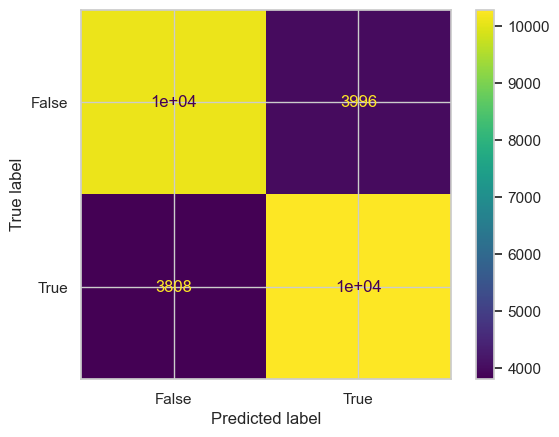

In [38]:
from sklearn import metrics

# Random forest classifier prediction
predicted = RandomForestClassifier(n_estimators=404,
                                   # max_depth=8,
                                   min_samples_split=10,
                                   min_samples_leaf=6,
                                   max_features='log2',
                                   criterion='gini',
                                   n_jobs=-1,
                                   random_state=42).fit(X_train,y_train).predict(X_test)

# # Calculate the confusion matrix
confusion_matrix = metrics.confusion_matrix(y_test, predicted)

# Extract TP, TN, FP, FN 
# Use .ravel() to flatten the 2x2 matrix into a 1x4 array: [TN, FP, FN, TP]
TN, FP, FN, TP = confusion_matrix.ravel()
conf_matrix_list = [TP, TN, FP, FN]

# Print the list with metrics
print(conf_matrix_list)

# Print the metrics
print("\n--- Classification Metrics ---")
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print("----------------------------\n")

# Display confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
cm_display.plot()
plt.show()

[<a href="#content">Back to top</a>]

## Matthews coefficient <a name="9"></a>

In [39]:
import math

def matthews_corr_coeff(TP: int, TN: int, FP: int, FN: int) -> float:
    """
    Calculates the Matthews Correlation Coefficient (MCC).

    MCC is a metric used to evaluate the quality of binary classifications.
    It takes into account true positives, true negatives, false positives, 
    and false negatives, making it a reliable measure even for imbalanced classes.

    The formula is:
    MCC = (TP * TN - FP * FN) / sqrt((TP + FP)(TP + FN)(TN + FP)(TN + FN))

    Args:
        TP (int): True Positives (correctly predicted positive cases).
        TN (int): True Negatives (correctly predicted negative cases).
        FP (int): False Positives (incorrectly predicted positive cases).
        FN (int): False Negatives (incorrectly predicted negative cases).

    Returns:
        float: The Matthews Correlation Coefficient, ranging from -1 (worst) 
               to +1 (best). Returns 0.0 if the denominator is zero.
    """
    
    # Calculate the numerator: (TP * TN) - (FP * FN)
    numerator = (TP * TN) - (FP * FN)
    
    # Calculate the components of the denominator
    # Note: These components are the marginal sums (sums of rows/columns in the confusion matrix)
    term_1 = TP + FP
    term_2 = TP + FN
    term_3 = TN + FP
    term_4 = TN + FN
    
    # Calculate the denominator: sqrt((TP + FP)(TP + FN)(TN + FP)(TN + FN))
    denominator = math.sqrt(term_1 * term_2 * term_3 * term_4)
    
    # Handle the case where the denominator is zero (which means one of the marginal
    # sums is zero, indicating an ill-defined problem or a trivial prediction). 
    # In this case, MCC is conventionally set to 0.
    if denominator == 0:
        print("Warning: Denominator is zero. Returning MCC = 0.0")
        return 0.0
    
    # Calculate the final MCC value
    mcc = numerator / denominator
    return mcc

# --- Example Usage ---
# Example 1: Perfect Classification (MCC = 1.0)
# tp1, tn1, fp1, fn1 = 8560, 1035,641, 2440
tp1, tn1, fp1, fn1 = conf_matrix_list
mcc1 = matthews_corr_coeff(tp1, tn1, fp1, fn1)
print(f"--- Example 1: Perfect Model ---")
print(f"TP={tp1}, TN={tn1}, FP={fp1}, FN={fn1}")
print(f"MCC: {mcc1:.4f}\n")

--- Example 1: Perfect Model ---
TP=10292, TN=10104, FP=3996, FN=3808
MCC: 0.4466



[<a href="#content">Back to top</a>]

## Classification report <a name="10"></a>

In [40]:
from sklearn.metrics import classification_report

# Print the classification report 
target_names = ['Active (target 1) ', 'Inactive (target 0)']
print(classification_report(y_test, predicted, target_names=target_names))

                     precision    recall  f1-score   support

 Active (target 1)        0.73      0.72      0.72     14100
Inactive (target 0)       0.72      0.73      0.73     14100

           accuracy                           0.72     28200
          macro avg       0.72      0.72      0.72     28200
       weighted avg       0.72      0.72      0.72     28200



[<a href="#content">Back to top</a>]

 ## RFC Feature importance <a name="11"></a>

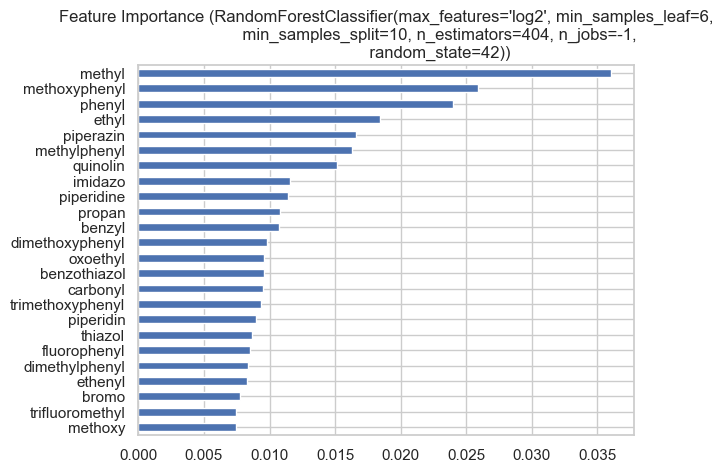

In [41]:
# Final model
model = RandomForestClassifier(n_estimators=404,
                                      # max_depth=8,
                                      min_samples_split=10,
                                      min_samples_leaf=6,
                                      max_features='log2',
                                      criterion='gini',
                                      n_jobs=-1,
                                      random_state=42).fit(X_train, y_train)

# Define feature importance of RandomForestClassifier 
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp = feat_imp.nlargest(24).sort_values()

# Plot feature importance of RandomForestClassifier 
feat_imp.plot(kind="barh", title="Feature Importance ({:})".format(model))
plt.show()

In [42]:
print(feat_imp[::-1])

methyl              0.036031
methoxyphenyl       0.025883
phenyl              0.024000
ethyl               0.018413
piperazin           0.016595
methylphenyl        0.016287
quinolin            0.015121
imidazo             0.011533
piperidine          0.011434
propan              0.010781
benzyl              0.010711
dimethoxyphenyl     0.009795
oxoethyl            0.009588
benzothiazol        0.009562
carbonyl            0.009484
trimethoxyphenyl    0.009351
piperidin           0.008995
thiazol             0.008639
fluorophenyl        0.008486
dimethylphenyl      0.008353
ethenyl             0.008274
bromo               0.007736
trifluoromethyl     0.007477
methoxy             0.007467
dtype: float64


[<a href="#content">Back to top</a>]

 ## Chi2 feature importance <a name="12"></a>

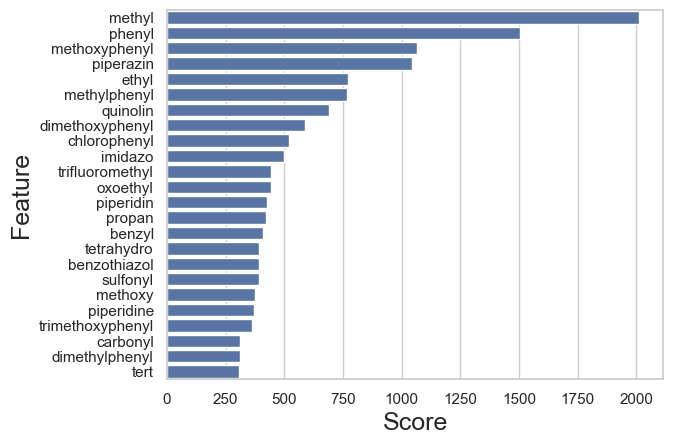

In [43]:
from sklearn.feature_selection import SelectKBest, chi2 
import seaborn as sns

# Feature selection 
sf = SelectKBest(chi2, k='all')

# Run score function on (X, y) and get the appropriate features.
sf_fit = sf.fit(X_train, y_train)

# Plot the scores
datset = pd.DataFrame()
datset['feature'] = X.columns[ range(len(sf_fit.scores_))]
datset['scores'] = sf_fit.scores_
datset = datset.sort_values(by='scores', ascending=False)
datset = datset.head(24) # Top 20 features 
sns.barplot(x=datset['scores'], y=datset['feature'])
sns.set_style('whitegrid')
plt.ylabel('Feature', fontsize=18)
plt.xlabel('Score', fontsize=18)
plt.show()

In [45]:
 print(datset)

               feature       scores
3081            methyl  2012.609556
4103            phenyl  1504.990500
3040     methoxyphenyl  1065.556894
4489         piperazin  1045.105730
2322             ethyl   771.636500
3268      methylphenyl   768.693737
4720          quinolin   688.719319
1586   dimethoxyphenyl   589.635473
782       chlorophenyl   521.825061
2866           imidazo   497.991435
5318   trifluoromethyl   443.236765
3733          oxoethyl   442.545800
4491         piperidin   427.007965
4496            propan   423.298446
382             benzyl   409.911456
5045        tetrahydro   393.802632
316       benzothiazol   391.398844
4873          sulfonyl   391.002571
2957           methoxy   375.165049
4492        piperidine   371.817331
5349  trimethoxyphenyl   362.090076
693           carbonyl   311.702411
1720    dimethylphenyl   309.355404
4987              tert   308.176101


[<a href="#content">Back to top</a>]

## Boruta feature importance   <a name="13"></a>

In [48]:
from boruta import BorutaPy

feature_names = X.columns.tolist() 

# Convert X to numpy array as required by BorutaPy (Boruta requires numpy arrays)
X_np = X.values
y_np = y.values

# Boruta Feature Selection
# Initialize Random Forest as the base estimator for Boruta
rf_estimator = RandomForestClassifier(n_estimators=404,
                                      # max_depth=8,
                                      min_samples_split=10,
                                      min_samples_leaf=6,
                                      max_features='log2',
                                      criterion='gini',
                                      n_jobs=-1,
                                      random_state=42) 

# Initialize Boruta
feat_selector = BorutaPy(
    rf_estimator,
    n_estimators='auto',
    max_iter=5,
    random_state=42
)

# Fit Boruta on the data
feat_selector.fit(X_np, y_np)

# Get the list of confirmed important features
selected_feature_indices = np.where(feat_selector.support_)[0]
final_features = [feature_names[i] for i in selected_feature_indices]

# Print Boruta results
print("\n--- Boruta Results ---")
print(f"Confirmed features: {final_features}")

# Print ranks of all features
feature_ranks = list(zip(feature_names, feat_selector.ranking_))
feature_ranks.sort(key=lambda x: x[1])
print("\nFeature Ranking (1 is the best):")
for name, rank in feature_ranks:
    print(f"  {name}: Rank {rank}")


--- Boruta Results ---
Confirmed features: []

Feature Ranking (1 is the best):
  acetamide: Rank 2
  acetate: Rank 2
  amine: Rank 2
  amino: Rank 2
  aminotetrazol: Rank 2
  azabicyclo: Rank 2
  azetidine: Rank 2
  benzimidazol: Rank 2
  benzo: Rank 2
  benzofuran: Rank 2
  benzohydrazide: Rank 2
  benzothiazepin: Rank 2
  benzothiazepine: Rank 2
  benzothiazol: Rank 2
  benzothiazole: Rank 2
  benzothiolo: Rank 2
  benzothiophen: Rank 2
  benzoxathiazocin: Rank 2
  benzoxazepin: Rank 2
  benzoxazocin: Rank 2
  benzoyl: Rank 2
  benzyl: Rank 2
  benzylpiperidin: Rank 2
  bicyclo: Rank 2
  bromide: Rank 2
  bromo: Rank 2
  bromophenyl: Rank 2
  butyl: Rank 2
  butylphenyl: Rank 2
  butyltetrazol: Rank 2
  carbamothioyl: Rank 2
  carbohydrazide: Rank 2
  carbonyl: Rank 2
  carbonylamino: Rank 2
  carboxamide: Rank 2
  chloro: Rank 2
  chloroacetyl: Rank 2
  chlorophenyl: Rank 2
  chloropyridin: Rank 2
  chloropyridine: Rank 2
  chromen: Rank 2
  cyanoethyl: Rank 2
  cyclopenta: Rank 2

In [49]:
from sklearn.model_selection import train_test_split

# Filter Data and Train RFC
if not final_features:
    print("\n[WARNING] Boruta did not confirm any features. Cannot proceed with RFC.")
else:
    X_filtered = X[final_features]
    print(f"\nTraining RFC using {len(final_features)} features.")

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y, test_size=0.3, stratify=y, random_state=42
    )

    # Random Forest Classifier Training and Evaluation
    print("\n--- Training Random Forest Classifier (RFC) ---")
    final_rfc = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1, # Use all available cores
    )
    
    final_rfc.fit(X_train, y_train)
    y_pred = final_rfc.predict(X_test_b)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nRFC Model Accuracy (on test set): {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Optional: Display feature importance from the final RFC model
    rfc_feature_importance = pd.Series(final_rfc.feature_importances_, index=final_features).sort_values(ascending=False)
    print("\nFeature Importance in Final RFC Model (Gini Importance):")
    print(rfc_feature_importance)


[WARNING] Boruta did not confirm any features. Cannot proceed with RFC.


[<a href="#content">Back to top</a>]

## LIME analyse <a name="14"></a>

In [47]:
from lime.lime_tabular import LimeTabularExplainer

# Turn in numpy array
X_train_np_full = X_train.values 
X_test_np_full = X_test.values   

# Create new variables _X_train and _X_test to be absolutely sure.
_X_train = X_train_np_full[:, 1:] 
_X_test = X_test_np_full[:, 1:]

FEATURE_COLUMNS = X.columns.tolist()
TARGET_CLASSES = ['Class 0', 'Class 1']

# Verification
print("--- Data Check ---")
print(f"X_train shape used for LIME: {_X_train.shape}")

# Use the correctly sliced arrays for the rest of the process
X_train_np = _X_train
X_test_np = _X_test

# Train a Classification Model
model = RandomForestClassifier(n_estimators=404,
                               # max_depth=8,
                               min_samples_split=10,
                               min_samples_leaf=6,
                               max_features='log2',
                               criterion='gini',
                               n_jobs=-1,
                               random_state=42) 
model.fit(X_train_np, y_train)

print(f"Model Accuracy: {model.score(X_test_np, y_test):.4f}")
print("-" * 30)

# Initialize LIME Explainer
feature_names = FEATURE_COLUMNS 

explainer = LimeTabularExplainer(
    training_data=X_train_np, 
    feature_names=feature_names,
    class_names=TARGET_CLASSES,
    mode='classification',
    discretize_continuous=True 
)

print("LIME Explainer Initialized.")
print("-" * 30)

# Explain a Single Prediction
instance_idx = 0
explanation_instance_np = X_test_np[instance_idx]
true_label = y_test.iloc[instance_idx] if hasattr(y_test, 'iloc') else y_test[instance_idx]

# Define the model's prediction function
prediction_function = model.predict_proba 

# print(f"Explaining instance: CID={explanation_instance_np[0]:.2f}, SID={explanation_instance_np[1]:.2f}")
print(f"True Label: {true_label}")
print(f"Model Prediction: {model.predict(explanation_instance_np.reshape(1, -1))[0]}") 
print("-" * 30)

# Generate the explanation 
exp = explainer.explain_instance(
    data_row=explanation_instance_np,
    predict_fn=prediction_function,
    num_features=2 
)

# Interpret the Explanation
print("LIME Explanation (Top 2 features and their influence):")
print(exp.as_list())

--- Data Check ---
X_train shape used for LIME: (94712, 5961)
Model Accuracy: 0.7235
------------------------------
LIME Explainer Initialized.
------------------------------
True Label: 1
Model Prediction: 1
------------------------------
LIME Explanation (Top 2 features and their influence):
[('phenoxythieno <= 0.00', -0.02044464674990125), ('methoxyxanthen <= 0.00', -0.00873276447439361)]


[<a href="#content">Back to top</a>]